# Prior Generating Function
- In the previous notebook, I found the peaks of the LSP signal for three stars.
- These signals matched up with those we know for those stars from the literature.
- There was typically more than one period in each range:
    - short (rot)
    - mid (solar)
    - long (Gleissberg)
- This will formally choose between them.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from astropy.time import Time
from astropy.timeseries import LombScargle

from scipy.signal import find_peaks
from scipy.optimize import curve_fit

from prettytable import PrettyTable

import sys
from pathlib import Path

sys.path.append(str(Path('..').resolve()))

from helpers.LSP_peaks import fit_peaks, set_period_axes
from helpers.df_ops import prepare_df, split_df


# Individual stars
raw_HD81809 = pd.read_csv(r"../Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
raw_HD160346 = pd.read_csv(r"../Data/benchmark/HD160346_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
raw_HD201091 =pd.read_csv(r"../Data/benchmark/HD201091_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)

data_HD81809 = prepare_df(raw_HD81809)
data_HD160346 = prepare_df(raw_HD160346)
data_HD201091 = prepare_df(raw_HD201091)

train_HD81809,  valid_HD81809,  test_HD81809  = split_df(data_HD81809)
train_HD160346, valid_HD160346, test_HD160346 = split_df(data_HD160346)
train_HD201091, valid_HD201091, test_HD201091 = split_df(data_HD201091)


C:\Users\Joey\AppData\Local\Temp\ipykernel_32636\2639658741.py:24: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  raw_HD81809 = pd.read_csv(r"../Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
C:\Users\Joey\AppData\Local\Temp\ipykernel_32636\2639658741.py:25: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  raw_HD160346 = pd.read_csv(r"../Data/benchmark/HD160346_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
C:\Users\Joey\AppData\Local\Temp\ipykernel_32636\2639658741.py:26: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex sepa

In [ ]:
def generate_priors(df,
        manual_freq = 'linear', period_range = [0.1, 100*365], n_periods = 100000,  # this is all the fit_peaks stuff
        FAPs = [10,5,1,0.1], key_FAP_idx = -1, 
        threshold = 5,
        plot_fitpeaks = True, verbose_fitpeaks = True,
        s_lim = 200, m_lim = 20 * 365, 
        plot_genpriors = True, verbose_genpriors = True,
        ):
    '''
    Generates the prior guesses for each of the three ranges for the spectrum kernel.

    Takes in the DF, calculates the LSP, identifies the peaks and the number thereof.
    It uses simple heuristics to classify them into long, mid, and short ranges.

    Params
    plot: plots LSP if True
    min_period, max_period in years
    n_periods to set the resolution
    s_lim = 150 days is approx what SM2016 says so 200 is safe
    m_lim = 14 years so do 20 * 365 to be safe
    
    Returns
    The peak periods and their concomitant ranges.
    '''
    peak_periods, peak_heights = fit_peaks(df, 
                    manual_freq = manual_freq, period_range = period_range, n_periods = n_periods,  # this is all the fit_peaks stuff
                    FAPs = FAPs, key_FAP_idx = key_FAP_idx, 
                    threshold = threshold,
                    plot = plot_fitpeaks, verbose = verbose_fitpeaks)

    # Now take the highest peak in each range
    priors = {}

    # Take a LS to compare the powers on the same scale
    t = df['day']
    y = df['sind']

    # ls = LombScargle(t, y)
    
    # peak_freqs = 1/peak_periods
    # peak_powers = ls.power(peak_freqs)

    ls = LombScargle(t, y)

    if manual_freq == 'linear':
        periods = np.linspace(period_range[0], period_range[1], n_periods)
    elif manual_freq == 'log':
        periods = np.logspace(np.log10(period_range[0]), np.log10(period_range[1]), n_periods)
    else:
        freqs, powers = ls.autopower()
        periods = 1 / freqs

    if manual_freq is not None:
        freqs = 1 / periods
        powers = ls.power(freqs)

    peak_powers = ls.power(1 / np.array(peak_periods))

    # Peak data
    peak_data = list(zip(peak_periods, peak_powers))

    peaks_s = [(p, pw) for p, pw in peak_data if p <= s_lim]
    peaks_m = [(p, pw) for p, pw in peak_data if s_lim < p <= m_lim]
    peaks_l = [(p, pw) for p, pw in peak_data if m_lim < p]

    if peaks_s:
            priors['short'] = max(peaks_s, key=lambda x: x[1])[0]
    if peaks_m:
            priors['mid'] = max(peaks_m, key=lambda x: x[1])[0]
    if peaks_l:
            priors['long'] = max(peaks_l, key=lambda x: x[1])[0]

    if plot_genpriors: # Plot first order LSP log-log and indicate the priors
        colors = {'short': 'red', 'mid': 'green', 'long': 'orange'}

        fig, ax = plt.subplots(figsize=(20,5))
        ax.set_xscale('log')
        ax.set_yscale('log')
        set_period_axes(ax)
       
        ax.plot(periods, powers, label = "LS Periodogram")
        
        for cycle_type, peak_period in priors.items():
                ax.axvline(peak_period, color = colors[cycle_type], label = f'Cycle type: {cycle_type}')
        
        ax.legend()
        plt.show()
    
    if verbose_genpriors:
        print("Priors")
        table = PrettyTable(["Cycle Type", "Prior Days", "Prior Years"])
        if priors.get('short'):
            table.add_row(["Short", f"{priors.get('short'):.2f}", f"{priors.get('short')/365:.2f}"])
        if priors.get('mid'):
            table.add_row(["Mid", f"{priors.get('mid'):.2f}", f"{priors.get('mid')/365:.2f}"])
        if priors.get('long'):
            table.add_row(["Long", f"{priors.get('long'):.2f}", f"{priors.get('long')/365:.2f}"])
        print(table)
    
    return priors

## HD81809

In iteration 0, period at 2991.66 days was accepted.
In iteration 1, period at 40.25 days was accepted.
In iteration 2, period at 44.27 days was accepted.
In iteration 3, period at 1813.07 days was accepted.
Peak at period 41.71 was identified to be an alias of 40.25 days at mult 1.00 by tolerance 0.04.
Peak at period 7119.84 was identified to be an alias of 1813.07 days at mult 4.00 by tolerance 0.02.
In iteration 4, period at 37.33 days was accepted.
In iteration 5, period at 6847.55 days was accepted.
Peak at period 42.44 was identified to be an alias of 44.27 days at mult 1.00 by tolerance 0.04.
Peak at period 21.27 was identified to be an alias of 44.27 days at mult 0.50 by tolerance 0.04.
Peak at period 38.06 was identified to be an alias of 37.33 days at mult 1.00 by tolerance 0.02.
Period of 47.19 failed SNR > 5 with SNR of 4.633401992630882
Iteration 6 did not find a frequency: terminating loop.


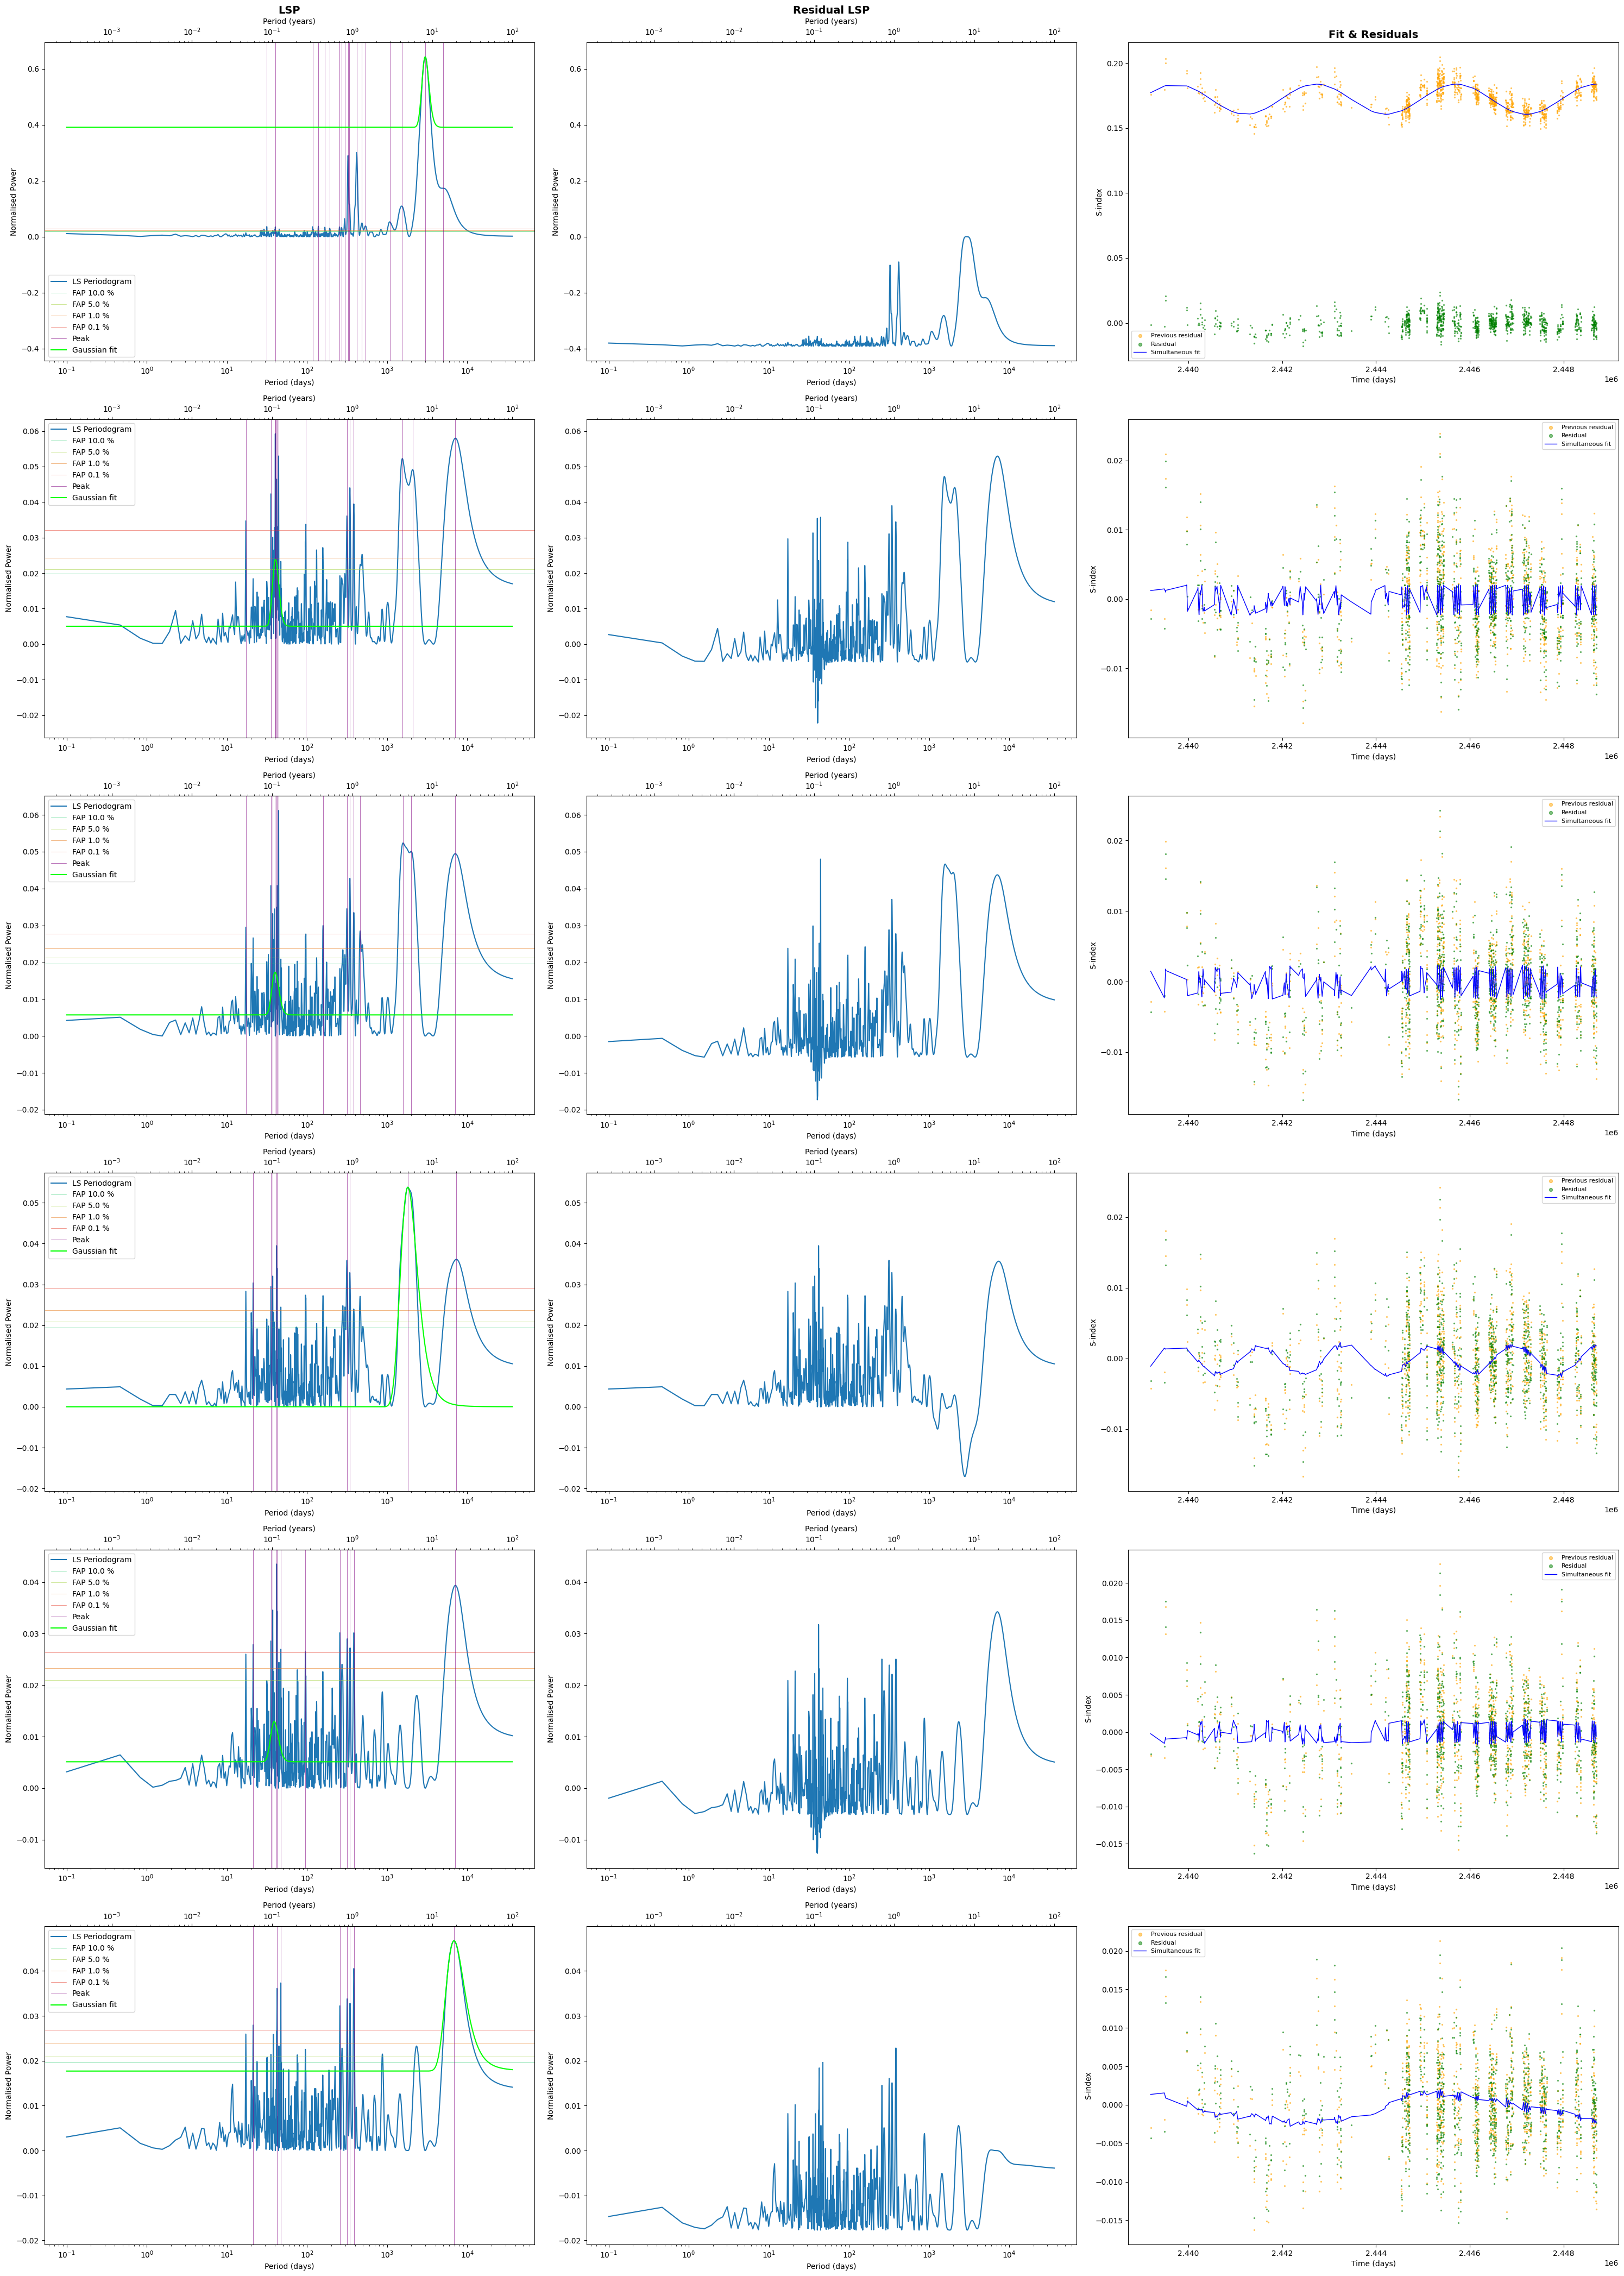

Accepted periods and their heights
+---------+-------+--------+------------+
|   Days  | Years | Height |    SNR     |
+---------+-------+--------+------------+
| 2991.66 |  8.20 |  0.64  |  76181.21  |
|  40.25  |  0.11 |  0.06  |    8.76    |
|  44.27  |  0.12 |  0.06  |    8.00    |
| 1813.07 |  4.97 |  0.05  |  3539.12   |
|  37.33  |  0.10 |  0.03  |    5.32    |
| 6847.55 | 18.76 |  0.05  | 3575428.99 |
+---------+-------+--------+------------+


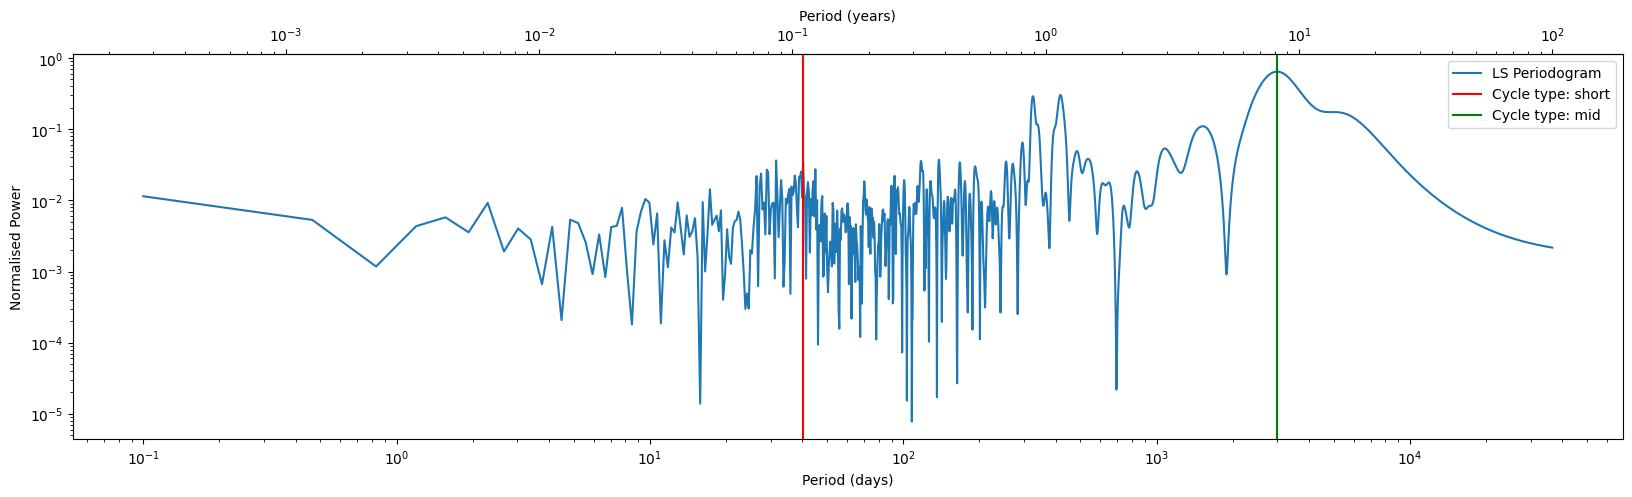

Priors
+------------+------------+-------------+
| Cycle Type | Prior Days | Prior Years |
+------------+------------+-------------+
|   Short    |   40.25    |     0.11    |
|    Mid     |  2991.66   |     8.20    |
+------------+------------+-------------+


{'short': np.float64(40.25029150291503), 'mid': np.float64(2991.6617196171965)}

In [17]:
generate_priors(train_HD81809)

- Compared to the literature value of 39.3 days and 8.2 years, this is perfect!!!


## HD160346

In [ ]:
generate_priors(train_HD160346)

- Real values are 35.3 daya and 7 years.

## HD201091


In [ ]:
generate_priors(train_HD201091)

- Literature values are 34 days and 7.3 years.